In [52]:
testrun = "false"
# testrun = "true"
version = "1_noLR"

In [2]:
print(testrun)

false


# Evaluate with GPT-4

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pickle


In [5]:
import re
import openai
import pandas as pd
import random


import sys
import os
import tiktoken
from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)  # for exponential backoff

In [6]:
from langchain_openai import AzureChatOpenAI
	
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ChatMessageHistory

from langchain.prompts.chat import ChatPromptTemplate
from langchain_core.runnables.history import RunnableWithMessageHistory

from langchain.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate

In [7]:
from brush_llm_funcs import brush_prepost_prob_llm, brush_get_probs_from_llm, brush_get_llm_responses

In [8]:
%load_ext dotenv
%dotenv /vast/palmer/home.mccleary/vs428/Documents/DischargeMe/hail-dischargeme/.env

In [9]:
# openai.api_type = "azure"
engine = "decile-gpt-4-128K"

In [10]:
os.environ['AZURE_OPENAI_ENDPOINT'] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ['AZURE_OPENAI_API_KEY'] = os.getenv("AZURE_OPENAI_KEY")
os.environ["OPENAI_API_VERSION"] = "2023-12-01-preview"

In [11]:
def num_tokens_from_string(string: str, encoding_name: str="cl100k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [12]:
from IPython.display import display, HTML

def add_line_breaks(text):
    return text.replace('\n', '<br>')


def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

In [15]:
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases_noLR.csv", sep="|",  engine="c")

In [16]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [17]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [18]:
with pd.option_context("display.max_colwidth", 2000):
    display(data.sample(5))

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr
12,12,13,ACS,high,"recent stent, not taking clopidogrel","A 45 year-old man presents to the ED with chest pain. He has a longstanding history of hypertension, obesity, and continues to smoke. Three months ago, he presented with unstable angina, underwent cardiac catheterization and stenting of the obtuse marginal artery with a drug eluting stent. He was discharged and instructed to take a new medicine in addition to aspirin. The medicine was expensive, however, and he stopped taking that medication about a week ago. This morning at work, he developed chest pain described as a severe mid chest tightness without radiation, associated with sweating. He drove himself to the ED. He took a sublingual nitroglycerin in route and his pain is now 2/10 in intensity.\n\nPMH is remarkable for hypertension and coronary artery disease. Medications are metoprolol, amlodipine, atorvastatin, aspirin, and prasugrel, which he recently stopped. \n\nHe lives with his wife and son and works as a plumber. He continues to smoke 1 ppd and is trying to stop. He drinks beers on the weekends.\n\nOn examination, HR=90, BP=130/90, RR=20. He is in moderate distress due to pain. Lungs are clear, cardiac exam is unremarkable. The chest is non-tender and the abdomen is benign.","A troponin level was drawn and reported back from the lab as [normal or abnormal]. Studies show that troponin testing in this setting has a sensitivity of 95%, specificity of 80% and a positive likelihood ratio of 4.75 and a negative likelihood ratio of 0.25.",What is the probability that this patient has an acute myocardial infarction?,Now what is the probability that this patient has an acute myocardial infarction?,4.75,0.25
4,4,5,ACS,medium,ACS versus hypertensive emergency,"A 50 year-old woman presents to the ED with chest pain. She has a longstanding history of hypertension for which takes three medications. She also has a history of borderline diabetes. She ran out of her blood pressure medications 3 days ago and hasn't been able to get into see her primary care doctor to get a renewal for her prescriptions. Yesterday, she began having chest pain described as a pressure in the mid chest without radiation. The pain occurred off and on throughout the day. She was relatively inactive yesterday and the pain did not seem to worsen with activity. She felt mildly short of breath along with the pain. She decided to come to the ED today because the pain was persisting, and also to see if she could get a refill on her BP medications. She is complaining of 3/10 mid sub-sternal chest tightness.\n\nPMH is remarkable for a 5-year history of hypertension and borderline diabetes controlled with diet. She normally takes dyazide, metoprolol, and amlodipine for hypertension.\n\nShe is married and works as a waitress. She quit smoking 3 years ago and drinks occasionally.\n\nOn examination, HR=100, BP=200/110, RR=28. She is obese in mild distress due to pain. HEENT is unremarkable, Lungs are clear, Cardiac exam reveals a regular rate and rhythm and no murmurs. The abdomen is obese and benign.","A troponin level was drawn and reported back from the lab as [normal or abnormal]. Studies show that troponin testing in this setting has a sensitivity of 95%, specificity of 80% and a positive likelihood ratio of 4.75 and a negative likelihood ratio of 0.25.",What is the probability that this patient has an acute myocardial infarction?,Now what is the probability that this patient has an acute myocardial infarction?,4.75,0.25
37,37,8,Pulmonary Embolism,medium,PE v Pneumonia,"A 54-year old woman presents to the emergency department after a sudden attack of shortness of breath. This dyspnea was accompanied by retrosternal chest pain, which was worse on deep breathing. She has otherwise been feeling well this week other than a cough productive of clear or yellow sputum for several days, and had three episodes in which she co

In [19]:
llm = AzureChatOpenAI(
    deployment_name=engine
)

In [20]:
if testrun == "true":
    # data = data.sample(3)
    data = data.iloc[28:30]

# Run model

## Setup LangChain LLM Pipeline

In [65]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert physician estimating your confidence that a patient has a particular disease using only the clinical presentation you're reading.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

chain = prompt | llm

In [66]:
pretest_template = "{case}\n\n{question1} Let's think step by step. First, explain your reasoning, and then give your answer. {format_instructions}"

posttest_template = "{labresult}\n\n{question2} Let's think step by step. First, explain your reasoning, and then give your answer. {format_instructions}"

In [67]:
format_instructions = "Your response should be a SINGLE numerical probability estimate in the form of `The likelihood of [condition] is [number]%.` DO NOT give a range."

## Negative Lab Results

In [42]:
def compute_true_bayesian_update(pre_test, lr):
    if pre_test == 1:
        odds = ((pre_test)/(1-pre_test+ 10**-10)) * lr    
    else:
        odds = ((pre_test)/(1-pre_test)) * lr
    post_test = odds / (1 + odds)
    return post_test
    

In [68]:
data['case_type'].value_counts()

case_type
PNEUMONIA    2
Name: count, dtype: int64

In [69]:
neg_chat_histories = brush_prepost_prob_llm(chain, data,
                       pretest_template, posttest_template, format_instructions, 
                       positive=False,
                       verbose=False)


Current row: 28
Current row: 29


In [53]:
pickle.dump(neg_chat_histories, open(f"neg_chat_histories_{version}.pickle", "wb" ) )
# import pandas as pd
# import pickle
# neg_chat_histories = pickle.load(open(f"neg_chat_histories_{version}.pickle", "rb"))

In [54]:
neg_pretest_probs, neg_posttest_probs = brush_get_probs_from_llm(neg_chat_histories)

In [55]:
neg_pretest_responses, neg_posttest_responses = brush_get_llm_responses(neg_chat_histories)

In [56]:
neg_pretest_probs

[5.0,
 5.0,
 5.0,
 10.0,
 30.0,
 10.0,
 15.0,
 40.0,
 20.0,
 70.0,
 90.0,
 70.0,
 70.0,
 1.0,
 20.0,
 30.0,
 10.0,
 85.0,
 80.0,
 85.0,
 70.0,
 85.0,
 95.0,
 95.0,
 95.0,
 95.0,
 5.0,
 70.0,
 60.0,
 90.0,
 5.0,
 5.0,
 10.0,
 15.0,
 70.0,
 30.0,
 70.0,
 70.0,
 30.0,
 70.0,
 85.0,
 70.0,
 85.0]

In [57]:
neg_probs_df = pd.DataFrame({"pretest_prob":neg_pretest_probs, "posttest_prob":neg_posttest_probs})

In [58]:
neg_response_df = pd.DataFrame({"pretest_llm_output":neg_pretest_responses, "posttest_llm_output":neg_posttest_responses})

In [59]:
neg_data_with_gpt = pd.concat([data, neg_probs_df, neg_response_df],axis=1)

In [60]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "Asthma Exacerbation v CAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]

neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "HCAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]
# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

neg_data_with_gpt['true_posttest'] = neg_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['neg_lr']) * 100, axis=1)

neg_data_with_gpt['positive'] = False

In [61]:
neg_data_with_gpt.to_csv(f"all_cases_neg_gpt4_output_{version}.csv", index=False)

## Positive Lab Results

In [62]:
pos_chat_histories = brush_prepost_prob_llm(chain, data, 
                       pretest_template, posttest_template, format_instructions, 
                       positive=True,
                       verbose=False)


NameError: name 'chain' is not defined

In [63]:
pickle.dump(pos_chat_histories, open(f"pos_chat_histories_{version}.pickle", "wb" ) )
# import pandas as pd
# import pickle
# pos_chat_histories = pickle.load(open(f"pos_chat_histories_{version}.pickle", "rb"))

In [64]:
pos_pretest_probs, pos_posttest_probs = brush_get_probs_from_llm(pos_chat_histories)

In [65]:
pos_pretest_responses, pos_posttest_responses = brush_get_llm_responses(pos_chat_histories)

In [66]:
pos_pretest_probs

[5.0,
 5.0,
 10.0,
 10.0,
 20.0,
 10.0,
 15.0,
 30.0,
 30.0,
 70.0,
 90.0,
 70.0,
 70.0,
 5.0,
 20.0,
 30.0,
 5.0,
 70.0,
 90.0,
 80.0,
 70.0,
 90.0,
 95.0,
 90.0,
 95.0,
 95.0,
 5.0,
 75.0,
 60.0,
 90.0,
 1.0,
 5.0,
 10.0,
 10.0,
 30.0,
 30.0,
 70.0,
 65.0,
 30.0,
 85.0,
 85.0,
 85.0,
 85.0]

In [67]:
pos_probs_df = pd.DataFrame({"pretest_prob":pos_pretest_probs, "posttest_prob":pos_posttest_probs})

In [68]:
pos_response_df = pd.DataFrame({"pretest_llm_output": pos_pretest_responses, "posttest_llm_output": pos_posttest_responses})

In [69]:
pos_data_with_gpt = pd.concat([data, pos_probs_df, pos_response_df],axis=1)

In [70]:
# drop the Pulmonary Embolism test cases from the positive lab df, since they have hard coded "negative" d-dimer values
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['probability'] == "low")
& (pos_data_with_gpt['case_type'] == "Pulmonary Embolism"))]

In [71]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "URI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "PCP v ILI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

In [72]:
pos_data_with_gpt['true_posttest'] = pos_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['pos_lr']) * 100, axis=1)


In [73]:
pos_data_with_gpt['positive'] = True


In [74]:
pos_data_with_gpt.to_csv(f"all_cases_pos_gpt4_output_{version}.csv", index=False)

# Compute Bayesian Change Score

In [76]:
data_with_gpt = pd.concat([pos_data_with_gpt, neg_data_with_gpt], axis=0)

In [77]:
data_with_gpt['bayes_diff'] = data_with_gpt['true_posttest'] - data_with_gpt['posttest_prob']

In [78]:
data_with_gpt.to_csv(f"all_cases_posneg_gpt4_output_{version}.csv", index=False)

# Plot

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
results = pd.DataFrame([(neg_data_with_gpt['true_posttest'] - neg_data_with_gpt['posttest_prob']).tolist(), 
                        (pos_data_with_gpt['true_posttest'] - pos_data_with_gpt['posttest_prob']).tolist()]).T.rename({0:"negative test", 1:"positive test"}, axis=1)

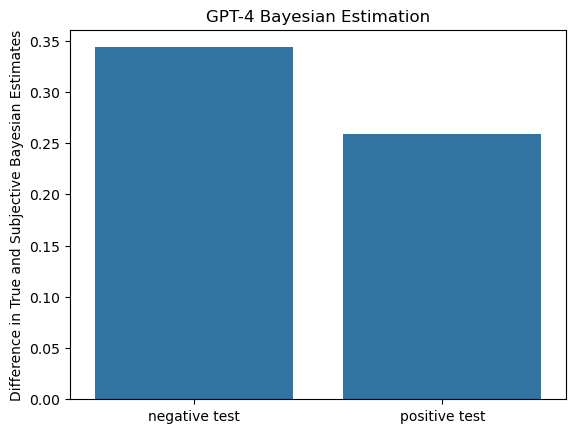

In [81]:
fig = sns.barplot(results.mean(), )
plt.ylabel("Difference in True/Subjective Bayesian Estimates\nwith no Likelihood Ratios")
plt.title("GPT-4 Bayesian Estimation")
plt.savefig(f"difference_{version}.png", bbox_inches="tight")

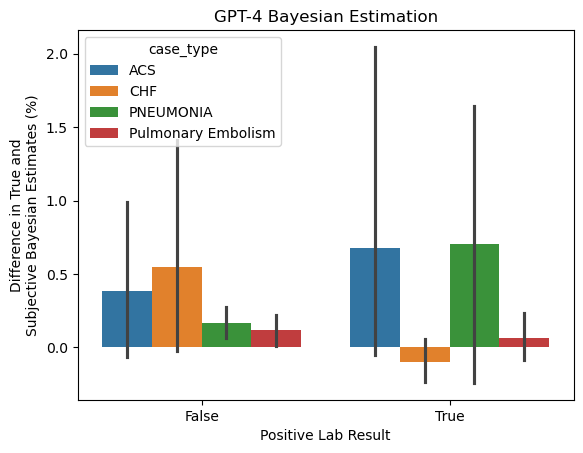

In [82]:
fig = sns.barplot(data_with_gpt, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation with no Likelihood Ratios")
plt.savefig(f"difference_by_condition_{version}.png", bbox_inches="tight")